In [1]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from helper.plot import plot_prof
from helper.diff_utils import diff_profile_shift
import scipy
from scipy.optimize import curve_fit
from scipy.special import erfc

In [2]:
# ---- Loading data ----
import sys

if sys.platform == "win32": # windows
    depth_df = pd.read_csv(r'C:\Users\t139116uhn\OneDrive - UHN\vis_test (caprese) results\vis_x.csv', dtype = float)
    time_df = pd.read_csv(r'C:\Users\t139116uhn\OneDrive - UHN\vis_test (caprese) results\vis_time.csv', dtype = float)
    conc_df = pd.read_csv(r'C:\Users\t139116uhn\OneDrive - UHN\vis_test (caprese) results\vis_conc_xt.csv', dtype = float)

elif sys.platform == "darwin": # mac
    depth_df = pd.read_csv('/Users/isaac/Library/CloudStorage/OneDrive-UHN/vis_test (caprese) results/vis_x.csv', dtype = float)
    time_df = pd.read_csv('/Users/isaac/Library/CloudStorage/OneDrive-UHN/vis_test (caprese) results/vis_time.csv', dtype = float)
    conc_df = pd.read_csv('/Users/isaac/Library/CloudStorage/OneDrive-UHN/vis_test (caprese) results/vis_conc_xt.csv', dtype = float)

In [3]:
# convert to np arrayx
depth = np.asarray(depth_df, dtype = float).flatten()
time = np.asarray(time_df, dtype = float).flatten()
conc = np.asarray(conc_df, dtype = float)

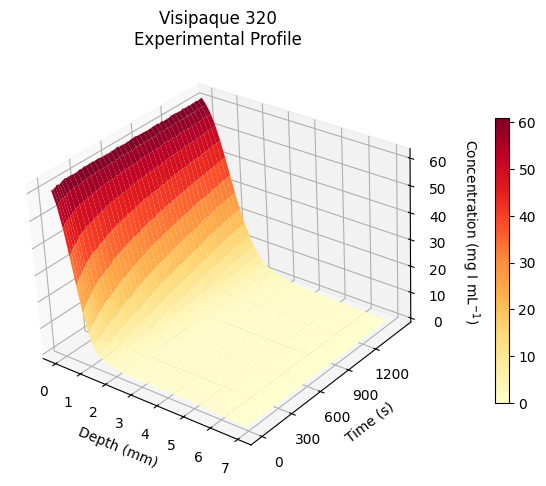

In [4]:
fig, ax = plt.subplots(1, 1, subplot_kw = {"projection": "3d"}, figsize = (6, 6), squeeze = False)
ax = ax.flatten()

depth_mesh, time_mesh = np.meshgrid(depth, time)

plot_prof(fig, ax, 0, x = depth_mesh, y = time_mesh, z = conc, 
          name = "Visipaque 320\nExperimental Profile", 
          elem = "I")
plt.tight_layout()
plt.show()

In [5]:
fit_model = diff_profile_shift

In [6]:
def diff_free(c_xt, x, time,
              fit_indices=None,
              d_init=1e-4,
              min_points=3):
    T, _ = c_xt.shape
    d_per_t = np.full(T, np.nan)
    cs_per_t = np.full(T, np.nan)
    x0_per_t = np.full(T, np.nan)
    r2_per_t = np.full(T, np.nan)
    rmse_per_t = np.full(T, np.nan)
    se_x0_per_t = np.full(T, np.nan)
    se_d_per_t = np.full(T, np.nan)
    se_cs_per_t = np.full(T, np.nan)
    lb_d_per_t = np.full(T, np.nan)
    ub_d_per_t = np.full(T, np.nan)
    lb_cs_per_t = np.full(T, np.nan)
    ub_cs_per_t = np.full(T, np.nan)
    corr_per_t = {}

    if fit_indices is None:
        fit_indices = range(1, T)

    alpha = 0.05

    print("--------")
    print("Reporting Results")
    print("--------")
    
    for i in fit_indices:
        t_i = time[i]
        if t_i <= 0:
            continue

        c_profile = c_xt[i, :]
        mask_valid = np.isfinite(c_profile)
        x_fit = x[mask_valid].flatten()
        c_fit = c_profile[mask_valid].flatten()

        if len(x_fit) < min_points:
            print(f"t = {t_i}: {len(x_fit)} points valid. Skipping.")
            continue
        x0_guess = 0

        p0 = [x0_guess, d_init, np.nanmax(c_fit)]
        lower = [0, 0, 0]
        upper = [1, np.inf, np.inf]

        def model(x_seg, x0, D, Cs):
            return fit_model(x_seg, x0, D, Cs, t_i)
        
        try:
            popt, pcov = curve_fit(
                model,
                x_fit, c_fit,
                p0=p0,
                bounds=(lower, upper)
            )

            x0_fit, D_fit, Cs_fit = popt

            # pcov diagnostics
            if np.any(np.diag(pcov) < 0):
                print(f"t = {t_i}: WARNING: Negative variance in pcov.")
            if np.any(~np.isfinite(pcov)):
                print(f"t = {t_i}: WARNING: pcov contains inf/nan.")

            stdevs = np.sqrt(np.diag(pcov))
            n_obs = len(c_fit)
            df = max(0, n_obs - 2)
            tval = scipy.stats.t.ppf(1.0 - alpha / 2.0, df)
            ci = tval * stdevs

            # Store results
            d_per_t[i] = D_fit
            cs_per_t[i] = Cs_fit
            x0_per_t[i] = x0_fit
            se_x0_per_t[i] = stdevs[0]
            se_d_per_t[i] = stdevs[1]
            se_cs_per_t[i] = stdevs[2]
            lb_d_per_t[i] = popt[0] - ci[0]
            ub_d_per_t[i] = popt[0] + ci[0]
            lb_cs_per_t[i] = popt[1] - ci[1]
            ub_cs_per_t[i] = popt[1] + ci[1]

            # Correlation matrix (2x2 for D and Cs)
            with np.errstate(invalid='ignore'):
                corr_per_t[i] = pcov / np.outer(stdevs, stdevs)

            # R2
            c_pred = fit_model(x_fit, x0_fit, D_fit, Cs_fit, t_i)
            ss_res = np.sum((c_fit - c_pred) ** 2)
            ss_tot = np.sum((c_fit - np.mean(c_fit)) ** 2)
            r2_per_t[i] = 1 - (ss_res / ss_tot)

            # RMSE
            rmse_per_t[i] = np.sqrt(ss_res / (n_obs - 3))

            print(f"t = {t_i} s: "
                  f"D = {D_fit:.3e}, SE = {stdevs[0]:.3e} "
                  f"(95% CI [{lb_d_per_t[i]:.3e}, {ub_d_per_t[i]:.3e}]), "
                  f"Cs = {Cs_fit:.3f}, SE = {stdevs[1]:.3f} "
                  f"(95% CI [{lb_cs_per_t[i]:.3f}, {ub_cs_per_t[i]:.3f}]), "
                  f"R2 = {r2_per_t[i]:.4f}, "
                  f"D-Cs corr = {corr_per_t[i][0, 1]:.3f}")

        except Exception as e:
            print(f"t = {t_i}: Fit FAILED -> {type(e)}: {e}")

    return {
        'd_per_t':     d_per_t,
        'se_d_per_t':  se_d_per_t,
        'cs_per_t':    cs_per_t,
        'se_cs_per_t': se_cs_per_t,
        'x0_per_t' : x0_per_t,
        "se_x0_per_t": se_x0_per_t,
        'r2_per_t':    r2_per_t,
        'rmse_per_t': rmse_per_t,
        'lb_d_per_t':  lb_d_per_t,
        'ub_d_per_t':  ub_d_per_t,
        'lb_cs_per_t': lb_cs_per_t,
        'ub_cs_per_t': ub_cs_per_t,
        'corr_per_t':  corr_per_t,   # dict of 2x2 corr matrices keyed by time index
    }

In [7]:
opt_free = diff_free(c_xt = conc, x = depth, time = time)

--------
Reporting Results
--------
t = 10.0 s: D = 1.020e-02, SE = 1.545e-02 (95% CI [5.431e-01, 6.056e-01]), Cs = 33.889, SE = 0.001 (95% CI [0.009, 0.011]), R2 = 0.9986, D-Cs corr = -0.838
t = 20.0 s: D = 5.586e-03, SE = 2.049e-02 (95% CI [5.327e-01, 6.155e-01]), Cs = 34.378, SE = 0.000 (95% CI [0.005, 0.006]), R2 = 0.9979, D-Cs corr = -0.852
t = 30.0 s: D = 3.494e-03, SE = 1.612e-02 (95% CI [5.627e-01, 6.278e-01]), Cs = 33.874, SE = 0.000 (95% CI [0.003, 0.004]), R2 = 0.9984, D-Cs corr = -0.832
t = 40.0 s: D = 2.766e-03, SE = 1.801e-02 (95% CI [5.615e-01, 6.343e-01]), Cs = 34.142, SE = 0.000 (95% CI [0.002, 0.003]), R2 = 0.9982, D-Cs corr = -0.840
t = 50.0 s: D = 2.236e-03, SE = 1.559e-02 (95% CI [5.726e-01, 6.356e-01]), Cs = 34.305, SE = 0.000 (95% CI [0.002, 0.003]), R2 = 0.9987, D-Cs corr = -0.838
t = 60.0 s: D = 1.884e-03, SE = 1.939e-02 (95% CI [5.746e-01, 6.529e-01]), Cs = 34.285, SE = 0.000 (95% CI [0.002, 0.002]), R2 = 0.9979, D-Cs corr = -0.835
t = 70.0 s: D = 1.709e-03, S

In [8]:
print("--------")
print("Free D, Free Cs")
print("--------")
print(f"r2: {np.nanmean(opt_free["r2_per_t"]):.3f}")
print(f"rmse: {np.nanmedian(opt_free["rmse_per_t"]):.3f} (IQR: {np.nanquantile(opt_free["rmse_per_t"], 0.25):.3e}–{np.nanquantile(opt_free["rmse_per_t"], 0.75):.3e})")
print(f"Median D: {np.nanmedian(opt_free["d_per_t"]):.3e} (IQR: {np.nanquantile(opt_free["d_per_t"], 0.25):.3e}–{np.nanquantile(opt_free["d_per_t"], 0.75):.3e})")
print(f"Median Cs at boundary: {np.nanmedian(opt_free["cs_per_t"]):.3f} (IQR: {np.nanquantile(opt_free["cs_per_t"], 0.25):.3f}–{np.nanquantile(opt_free["cs_per_t"], 0.75):.3f})")
print(f"Median x0: {np.nanmedian(opt_free["x0_per_t"]):.3e} (IQR: {np.nanquantile(opt_free["x0_per_t"], 0.25):.3e}–{np.nanquantile(opt_free["x0_per_t"], 0.75):.3e})")


--------
Free D, Free Cs
--------
r2: 0.999
rmse: 0.655 (IQR: 6.077e-01–6.843e-01)
Median D: 2.914e-04 (IQR: 2.386e-04–4.901e-04)
Median Cs at boundary: 34.338 (IQR: 34.123–34.611)
Median x0: 8.633e-01 (IQR: 7.374e-01–9.483e-01)


In [9]:
corrfree_per_t = opt_free['corr_per_t']
valid_idx = np.where(np.isfinite(opt_free["cs_per_t"]))[0]

print("--------")
print("D-Cs correlations per timepoint")
print("--------")
corr_summary = {}
pos_corr = {}

for t_idx in valid_idx:
    corr_t = corrfree_per_t[t_idx][0, 1]  # 2x2 matrix, D-Cs is [0,1]
    label = f"t={time[t_idx]}s"
    corr_summary[label] = corr_t
    if abs(corr_t) >= 0.3:
        pos_corr[label] = corr_t

if not pos_corr:
    print("Weak to no correlations detected.")
else:
    print("Moderate to strong correlations detected:")
    for label, val in pos_corr.items():
        print(f"  D vs Cs at {label}: {val:.3f}")

--------
D-Cs correlations per timepoint
--------
Moderate to strong correlations detected:
  D vs Cs at t=10.0s: -0.838
  D vs Cs at t=20.0s: -0.852
  D vs Cs at t=30.0s: -0.832
  D vs Cs at t=40.0s: -0.840
  D vs Cs at t=50.0s: -0.838
  D vs Cs at t=60.0s: -0.835
  D vs Cs at t=70.0s: -0.844
  D vs Cs at t=80.0s: -0.835
  D vs Cs at t=90.0s: -0.836
  D vs Cs at t=100.0s: -0.832
  D vs Cs at t=110.0s: -0.821
  D vs Cs at t=130.0s: -0.824
  D vs Cs at t=150.0s: -0.821
  D vs Cs at t=170.0s: -0.815
  D vs Cs at t=190.0s: -0.816
  D vs Cs at t=210.0s: -0.819
  D vs Cs at t=230.0s: -0.817
  D vs Cs at t=250.0s: -0.824
  D vs Cs at t=270.0s: -0.826
  D vs Cs at t=290.0s: -0.816
  D vs Cs at t=310.0s: -0.831
  D vs Cs at t=330.0s: -0.811
  D vs Cs at t=350.0s: -0.836
  D vs Cs at t=370.0s: -0.817
  D vs Cs at t=390.0s: -0.814
  D vs Cs at t=410.0s: -0.819
  D vs Cs at t=430.0s: -0.815
  D vs Cs at t=450.0s: -0.826
  D vs Cs at t=470.0s: -0.805
  D vs Cs at t=490.0s: -0.813
  D vs Cs at t=51